Initial Data Preview:


,Department,Gender,HSC,SSC,Income,Hometown,Computer,Preparation,Gaming,Attendance,Job,English,Extra,Semester,Last,Overall
0,Business Administration,Male,4.17,4.84,"Low (Below 15,000)",Village,3,More than 3 Hours,0-1 Hour,80%-100%,No,3,Yes,6th,3.220,3.350
1,Business Administration,Female,4.92,5.00,"Upper middle (30,000-50,000)",City,3,0-1 Hour,0-1 Hour,80%-100%,No,3,Yes,7th,3.467,3.467
2,Business Administration,Male,5.00,4.83,"Lower middle (15,000-30,000)",Village,3,0-1 Hour,More than 3 Hours,80%-100%,No,4,Yes,3rd,4.000,3.720
3,Business Administration,Male,4.00,4.50,"High (Above 50,000)",City,5,More than 3 Hours,More than 3 Hours,80%-100%,No,5,Yes,4th,3.800,3.750
4,Business Administration,Female,2.19,3.17,"Lower middle (15,000-30,000)",Village,3,0-1 Hour,2-3 Hours,80%-100%,No,3,Yes,4th,3.940,3.940


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493 entries, 0 to 492
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Department   493 non-null    object 
 1   Gender       493 non-null    object 
 2   HSC          493 non-null    float64
 3   SSC          493 non-null    float64
 4   Income       493 non-null    object 
 5   Hometown     493 non-null    object 
 6   Computer     493 non-null    int64  
 7   Preparation  493 non-null    object 
 8   Gaming       493 non-null    object 
 9   Attendance   493 non-null    object 
 10  Job          493 non-null    object 
 11  English      493 non-null    int64  
 12  Extra        493 non-null    object 
 13  Semester     493 non-null    object 
 14  Last         493 non-null    float64
 15  Overall      493 non-null    float64
dtypes: float64(4), int64(2), object(10)
memory usage: 61.8+ KB


,HSC,SSC,Computer,English,Last,Overall
count,493.000000,493.000000,493.000000,493.000000,493.000000,493.000000
mean,4.156775,4.767647,3.338742,3.569980,3.163888,3.188383
std,0.546504,0.349538,1.252988,0.870515,0.641475,0.591801
min,2.170000,3.000000,1.000000,1.000000,1.000000,1.000000
25%,3.830000,4.680000,3.000000,3.000000,2.810000,2.880000
50%,4.170000,4.940000,3.000000,4.000000,3.250000,3.270000
75%,4.500000,5.000000,4.000000,4.000000,3.670000,3.680000
max,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000


/tmp/ipython-input-2027460347.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[column].fillna(X_train[column].median(), inplace=True)  # Fill missing numeric values in training data with median
/tmp/ipython-input-2027460347.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

Optimal number of features: 11
Selected Features: ['HSC', 'SSC', 'English', 'Last', 'Preparation_2-3 Hours', 'Gaming_2-3 Hours', 'Attendance_80%-100%', 'Job_Yes', 'Semester_11th', 'Semester_2nd', 'Semester_4th']
Optimal Alpha (λ) for Lasso Regression: 0.005429

Linear Regression Performance:
Mean Squared Error (MSE): 0.0468
R-Squared Score (R²): 0.8746


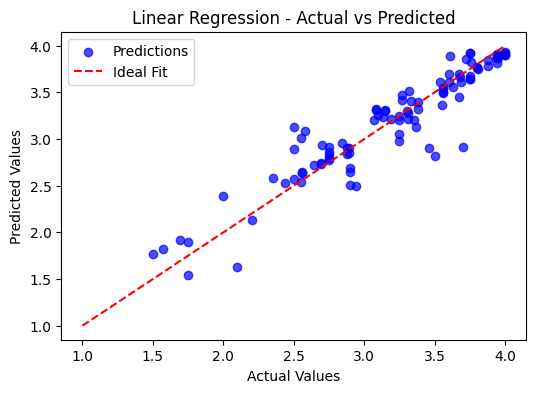


Lasso Regression (Optimized) Performance:
Mean Squared Error (MSE): 0.0389
R-Squared Score (R²): 0.8959


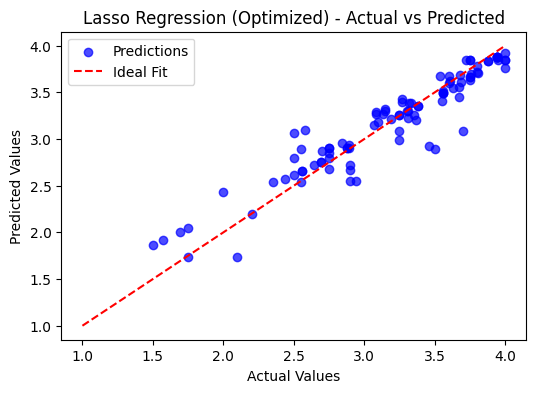


Ridge Regression Performance:
Mean Squared Error (MSE): 0.0482
R-Squared Score (R²): 0.8708


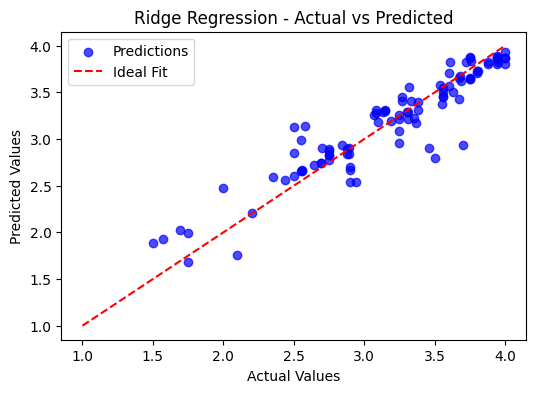

In [2]:
# Import necessary libraries for data manipulation, numerical operations, visualization, and machine learning
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting and visualization
import seaborn as sns  # For enhanced data visualization
from sklearn.model_selection import train_test_split  # For splitting data into training and testing sets
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # For scaling features
from sklearn.ensemble import RandomForestRegressor  # For using Random Forest in feature selection
from sklearn.feature_selection import RFECV  # For Recursive Feature Elimination with Cross-Validation
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV  # For various linear regression models
from sklearn.metrics import mean_squared_error, r2_score  # For evaluating model performance

# Load dataset from CSV file (replace 'ResearchInformation3.csv' with the actual filename if needed)
df = pd.read_csv("ResearchInformation3.csv")  # Read CSV file into a DataFrame

# Display first few rows of the dataset
print("Initial Data Preview:")  # Print a header for the data preview
display(df.head())  # Display the first 5 rows of the DataFrame

# Display information about the dataset, including data types and non-null counts
df.info()  # Print summary information about the DataFrame

# Display summary statistics for the dataset
display(df.describe())  # Show summary statistics for numeric columns

# Splitting data into features (X) and target variable (y)
X = df.drop(columns=['Overall'])  # Remove the target column 'Overall' to create feature set
y = df['Overall']  # Set the target variable

# Split the data into training and testing sets BEFORE any preprocessing steps
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 80% training, 20% testing

# Handling missing values for numeric columns by filling with the median from the training set
for column in X_train.select_dtypes(include=np.number).columns:  # Iterate over numeric columns in training data
    X_train[column].fillna(X_train[column].median(), inplace=True)  # Fill missing numeric values in training data with median
    X_test[column].fillna(X_train[column].median(), inplace=True)  # Fill missing numeric values in test data using training median

# Handling missing values for categorical columns by filling with the mode from the training set
for column in X_train.select_dtypes(include=['object']).columns:  # Iterate over categorical columns in training data
    X_train[column].fillna(X_train[column].mode()[0], inplace=True)  # Fill missing categorical values in training data with mode
    X_test[column].fillna(X_train[column].mode()[0], inplace=True)  # Fill missing categorical values in test data using training mode

# Detecting outliers in numeric features using the Interquartile Range (IQR) method
numeric_df = X_train.select_dtypes(include=np.number)  # Select only numeric columns from training data
Q1 = numeric_df.quantile(0.25)  # Compute the 25th percentile for each numeric column
Q3 = numeric_df.quantile(0.75)  # Compute the 75th percentile for each numeric column
IQR = Q3 - Q1  # Calculate the IQR for each numeric column

# Define lower and upper bounds for outlier detection based on the IQR
lower_bound = Q1 - 1.5 * IQR  # Set lower bound for detecting outliers
upper_bound = Q3 + 1.5 * IQR  # Set upper bound for detecting outliers

# Create a mask to filter out rows that contain any outliers
mask = ~((numeric_df < lower_bound) | (numeric_df > upper_bound)).any(axis=1)  # Identify rows without outliers
mask = mask.reindex(X_train.index)  # Ensure the mask has the same index as X_train

# Apply the mask to filter out outliers from the training data and corresponding target values
X_train = X_train[mask]  # Keep only rows in X_train that do not have outliers
y_train = y_train[mask]  # Keep corresponding rows in y_train

# Reset the indices of the training data after outlier removal
X_train.reset_index(drop=True, inplace=True)  # Reset index for X_train without adding a new column
y_train = y_train.reset_index(drop=True)  # Reset index for y_train

# One-Hot Encode categorical features to convert them into numerical format
X_train = pd.get_dummies(X_train, drop_first=True)  # Convert categorical variables in training data to dummy variables
X_test = pd.get_dummies(X_test, drop_first=True)  # Convert categorical variables in test data to dummy variables

# Align the training and testing datasets by ensuring they have the same dummy variable columns
missing_cols_train = set(X_test.columns) - set(X_train.columns)  # Identify dummy columns present in test but missing in train
for c in missing_cols_train:  # For each missing column in training data
    X_train[c] = 0  # Add the missing column to training data with all values set to 0

missing_cols_test = set(X_train.columns) - set(X_test.columns)  # Identify dummy columns present in train but missing in test
for c in missing_cols_test:  # For each missing column in test data
    X_test[c] = 0  # Add the missing column to test data with all values set to 0

X_test = X_test[X_train.columns]  # Reorder test data columns to match the order of training data columns

# Feature Selection using Recursive Feature Elimination with Cross-Validation (RFECV) and RandomForestRegressor
clf_rf = RandomForestRegressor(random_state=42)  # Initialize a RandomForestRegressor with a fixed random state
rfecv = RFECV(estimator=clf_rf, step=1, cv=5, scoring='neg_mean_squared_error')  # Set up RFECV for feature selection
rfecv.fit(X_train, y_train)  # Fit RFECV to the training data

# Print the optimal number of features and the list of selected features
print(f"Optimal number of features: {rfecv.n_features_}")  # Output the number of features selected by RFECV
selected_features = X_train.columns[rfecv.support_]  # Get the names of the features selected by RFECV
print(f"Selected Features: {list(selected_features)}")  # Output the list of selected features

# Transform the training and testing datasets to include only the selected features
X_train_selected = X_train[selected_features]  # Subset training data with selected features
X_test_selected = X_test[selected_features]  # Subset test data with selected features

# Standard Scaling: Scale features to have zero mean and unit variance
scaler = StandardScaler()  # Initialize the StandardScaler
X_train_scaled = scaler.fit_transform(X_train_selected)  # Fit the scaler on training data and transform it
X_test_scaled = scaler.transform(X_test_selected)  # Transform test data using the same scaler

# Min-Max Scaling: Scale features to a given range (default is 0 to 1)
minmax_scaler = MinMaxScaler()  # Initialize the MinMaxScaler
X_train_minmax = minmax_scaler.fit_transform(X_train_selected)  # Fit and transform training data using MinMaxScaler
X_test_minmax = minmax_scaler.transform(X_test_selected)  # Transform test data using the same MinMaxScaler

# Find the optimal alpha (λ) for Lasso Regression using cross-validation
alphas = np.logspace(-4, 1, 50)  # Create an array of 50 values ranging from 10^-4 to 10^1 for alpha
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)  # Initialize LassoCV with the array of alphas and 5-fold CV
lasso_cv.fit(X_train_minmax, y_train)  # Fit LassoCV on the min-max scaled training data

# Retrieve and print the optimal alpha determined by LassoCV
best_alpha = lasso_cv.alpha_  # Get the best alpha value from LassoCV
print(f"Optimal Alpha (λ) for Lasso Regression: {best_alpha:.6f}")  # Print the optimal alpha with six decimal places

# Define a dictionary of models to train and evaluate
models = {
    "Linear Regression": LinearRegression(),  # Linear Regression model
    "Lasso Regression (Optimized)": Lasso(alpha=best_alpha),  # Lasso Regression with optimized alpha
    "Ridge Regression": Ridge(alpha=1.0)  # Ridge Regression with default alpha value of 1.0
}

# Iterate over each model to train, predict, evaluate, and visualize the results
for name, model in models.items():  # Loop through each model in the dictionary
    model.fit(X_train_minmax, y_train)  # Train the model using the min-max scaled training data
    y_pred = model.predict(X_test_minmax)  # Predict target values for the test data

    # Evaluate the model's performance using Mean Squared Error and R-Squared metrics
    mse = mean_squared_error(y_test, y_pred)  # Calculate Mean Squared Error between actual and predicted values
    r2 = r2_score(y_test, y_pred)  # Calculate R-Squared score to measure model performance

    # Print the performance metrics for the current model
    print(f"\n{name} Performance:")  # Output the model's name
    print(f"Mean Squared Error (MSE): {mse:.4f}")  # Output the MSE rounded to four decimals
    print(f"R-Squared Score (R²): {r2:.4f}")  # Output the R² score rounded to four decimals

    # Plot the actual vs predicted values to visualize model performance
    plt.figure(figsize=(6, 4))  # Create a new figure with specified dimensions
    plt.scatter(y_test, y_pred, alpha=0.7, color='blue', label='Predictions')  # Plot a scatter plot of predictions vs actual values
    plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Ideal Fit')  # Plot the ideal line where predictions equal actual values
    plt.xlabel("Actual Values")  # Label the x-axis
    plt.ylabel("Predicted Values")  # Label the y-axis
    plt.title(f"{name} - Actual vs Predicted")  # Set the title of the plot including the model name
    plt.legend()  # Display the legend on the plot
    plt.show()  # Render the plot
